In [25]:
import numpy as np
from numpy. linalg import svd
# from sklearn.decomposition import TruncatedSVD

X= np.array([[3,4,3],[1,2,3], [4,2,1]])
U, E, VT = svd(X, full_matrices = False) # full_matrices=True
X_ = (U @ np.diag(E) @ VT)
Z = U[:, :2] . T @ X
q = 2
Xq = U[:, :q] @ U[:, :q].T @ X
print("x _= ", X_)
print("xq=", Xq) # projection matrix
# full_matrices=True

x _=  [[3. 4. 3.]
 [1. 2. 3.]
 [4. 2. 1.]]
xq= [[3.14122695 3.64995395 3.25613953]
 [0.85777624 2.35251674 2.74205258]
 [3.91790778 2.20347431 0.85111154]]


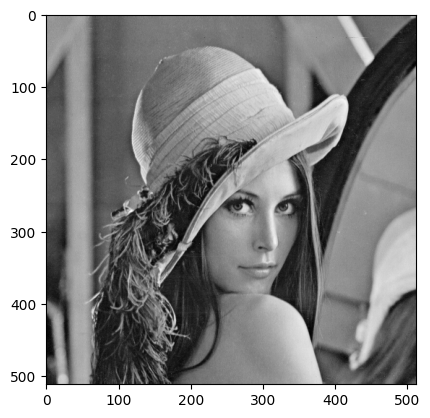

In [26]:
import numpy as np
from numpy.linalg import svd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
imgfile = 'Lenna.png' # 512x512x3
X = mpimg.imread(imgfile)
if len(X.shape) > 2:
    X = np.mean(X, axis=2) # convert RGB to grayscale(大於2代表是彩色圖)
plt.imshow(X,cmap = 'gray')
plt.show
N, p = X.shape
U, E, VT = svd(X, full_matrices = False)
q = np.array([p/4, p/8,p/16]).astype('int')

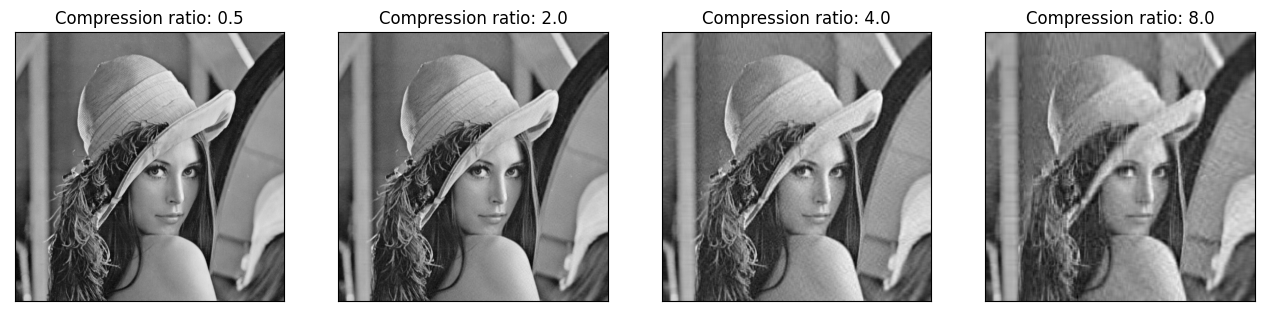

In [27]:
#影像壓縮
import numpy as np
from numpy.linalg import svd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
imgfile = 'Lenna.png' # 512x512x3
X = mpimg.imread(imgfile)
if len(X.shape) > 2:
    X = np.mean(X, axis=2) # convert RGB to grayscale(大於2代表是彩色圖)
p, N = X.shape # p by N, p = 512, N = 512
U, E, VT = svd(X, full_matrices = False)
q = np.array([p, p/4, p/8, p/16]) . astype('int')
# q = np.array([512, 200, 100, 50]).astype('int')
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for i, r in enumerate(q):
    Xq = U[:, :r] @ np.diag(E[:r]) @ VT[:r, :]
    ax[i].imshow(Xq, cmap = 'gray')
    ratio = p * N / (U.shape[0] + VT.shape[1] +1)/r #compression
    ax[i].set_title('Compression ratio: {:.1f}'.format(ratio))
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.show ()

In [28]:
import numpy as np

def montage(A, m, n):
    '''
    Create a montage matrix with mn images
    Inputs:
    A: original pxN image matrix with N images (p pixels), N > mn
    m, n: m rows & n columns, total mn images
    Output:
    M: montage matrix containing mn images
    '''

    sz = np.sqrt(A.shape[0]).astype('int') # image size sz x sz
    M = np.zeros((m*sz, n*sz)) # montage image
    for i in range(m) :
        for j in range(n) :
            M[i*sz: (i+1)*sz, j*sz:(j+1)*sz] = \
            A[:, i*n+j].reshape(sz, sz)
    return M

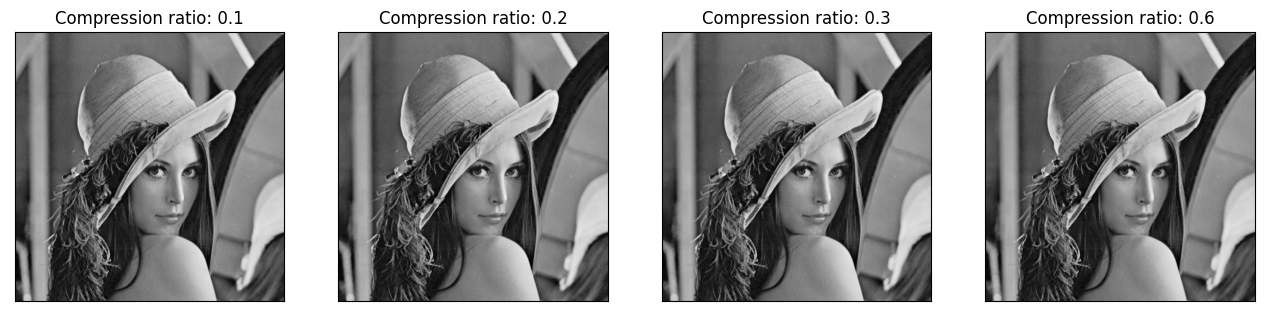

In [29]:
import numpy as np
from numpy.linalg import svd
import skimage.util as skutil
from skimage import io
import matplotlib.pyplot as plt

imgfile = "lenna.png" # 512x512x3
X = io.imread(imgfile, as_gray = True)

# 將圖像切割小區域
p, N = X.shape # p by N, p = 512, N = 512
patch_sz = 4
p_patch = patch_sz ** 2
N_patch = int(N * p / p_patch)
patches = skutil.view_as_windows(X, (patch_sz, patch_sz), \
                                 step=patch_sz)

M = np.empty((patch_sz*patch_sz, 0))  # initialize M as an empty array with shape (patch_sz*patch_sz,0)

for i in range(patches.shape[0]):
    for j in range(patches.shape[1]):
        patch = patches[i, j].reshape(-1, 1)
        M = np.append(M, patch, axis=1)  # append the reshaped patch to M

U, E, VT = svd(M, full_matrices = False)
q = np.array([256, 102, 51, 25]).astype('int')
# q = np.array([p/4, p/8, p/16]).astype('int')
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for i, r in enumerate(q):
    Mq = U[:, :r] @ np.diag(E[:r]) @ VT[:r, :]
    ax[i].imshow(montage(Mq, int(p/patch_sz), int(p/patch_sz)), cmap = 'gray')
    ratio = N * p / (U.shape[0] + VT.shape[1]) / r
    ax[i].set_title('Compression ratio: {:.1f}'.format(ratio))
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.show()

In [30]:
import numpy as np

def montage(A, m, n):
    '''
    Create a montage matrix with mn images
    Inputs:
    A: original pxN image matrix with N images (p pixels), N > mn
    m, n: m rows & n columns, total mn images
    Output:
    M: montage matrix containing mn images
    '''

    sz = np.sqrt(A.shape[0]).astype('int') # image size sz x sz
    M = np.zeros((m*sz, n*sz)) # montage image
    for i in range(m) :
        for j in range(n) :
            M[i*sz: (i+1)*sz, j*sz:(j+1)*sz] = \
            A[:, i*n+j].reshape(sz, sz)
    return M

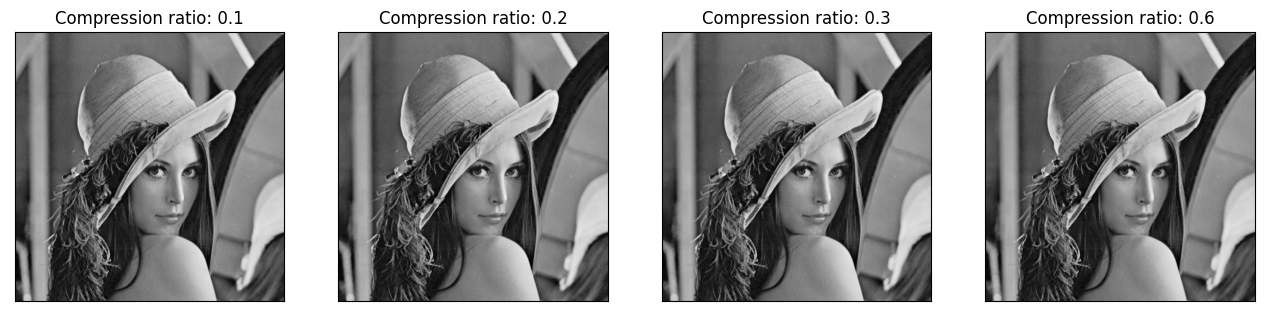

In [31]:
import numpy as np
from numpy.linalg import svd
import skimage.util as skutil
from skimage import io
import matplotlib.pyplot as plt

imgfile = "lenna.png" # 512x512x3
X = io.imread(imgfile, as_gray = True)

# 將圖像切割小區域
p, N = X.shape # p by N, p = 512, N = 512
patch_sz = 4
p_patch = patch_sz ** 2
N_patch = int(N * p / p_patch)
patches = skutil.view_as_windows(X, (patch_sz, patch_sz), \
                                 step=patch_sz)

M = np.empty((patch_sz*patch_sz, 0))  # initialize M as an empty array with shape (patch_sz*patch_sz,0)

for i in range(patches.shape[0]):
    for j in range(patches.shape[1]):
        patch = patches[i, j].reshape(-1, 1)
        M = np.append(M, patch, axis=1)  # append the reshaped patch to M

U, E, VT = svd(M, full_matrices = False)
q = np.array([256, 102, 51, 25]).astype('int')
# q = np.array([p/4, p/8, p/16]).astype('int')
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for i, r in enumerate(q):
    Mq = U[:, :r] @ np.diag(E[:r]) @ VT[:r, :]
    ax[i].imshow(montage(Mq, int(p/patch_sz), int(p/patch_sz)), cmap = 'gray')
    ratio = N * p / (U.shape[0] + VT.shape[1]) / r
    ax[i].set_title('Compression ratio: {:.1f}'.format(ratio))
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.show()

In [32]:
# from scipy.io import loadmat

# mnist = loadmat("mnist-original.mat")
# X = mnist["data"]
# y = mnist["label"][0]

In [33]:
from sklearn.datasets import fetch_openml
import pickle
import os
import numpy as np

data_file = 'mnist_digits_784.pkl'
# Check if data file exists
if os.path.isfile(data_file):
# Load data from file
  with open(data_file, 'rb') as f:
    data = pickle.load(f)
else:
# Fetch data from internet
  data = fetch_openml('mnist_784', version=1)
# Save data to file
  with open(data_file, 'wb') as f:
    pickle.dump(data, f)
X, y = np.array(data.data).T, np.array(data.target).astype('int')

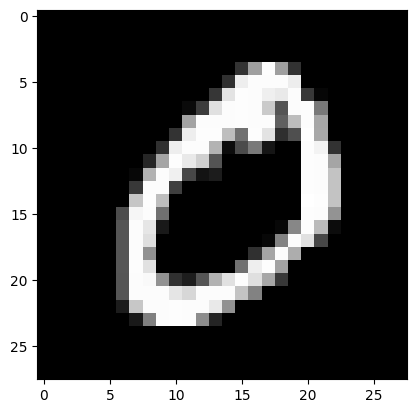

7877


In [34]:
import matplotlib.pyplot as plt
import numpy as np
i = 1
img = X[:, i]
sz = np.sqrt(len(img)).astype('int')
plt.imshow(np.array(img).reshape(sz, sz), cmap='gray')
plt.show()
print(sum(y==i))

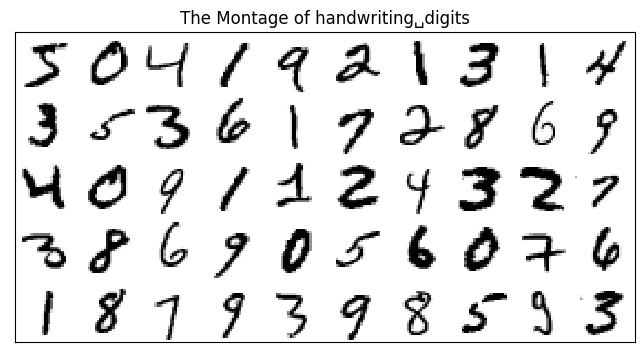

In [35]:
plt.figure(figsize = (8, 6))
m, n = 5, 10 # m x n montage (total mn images)
M = montage(X, m, n)
plt.imshow(M, cmap = plt.cm.gray_r, interpolation = 'nearest')
plt.xticks([])
plt.yticks([])
plt.title('The Montage of handwriting␣digits')
plt.show()

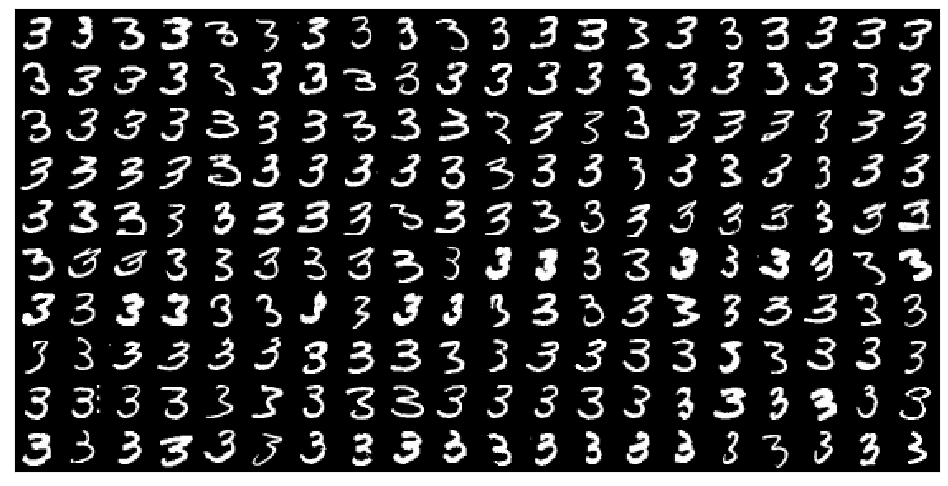

In [37]:
digit_to_show = 3
Digit = X[:, y==digit_to_show]
plt.figure(figsize = (12, 6))
m, n = 10, 20 # A m x n montage (total mn images)
M = montage(Digit, m, n)
plt.imshow(M, cmap = 'gray', interpolation = 'nearest')
plt.xticks([])
plt.yticks([])
plt.show()

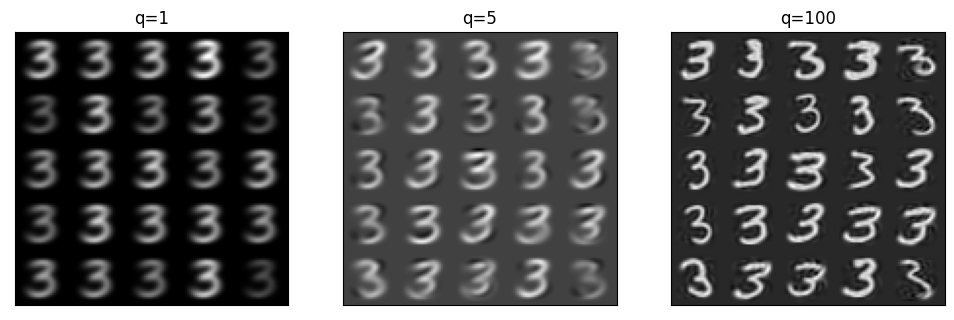

In [41]:
import numpy as np
from sklearn.datasets import fetch_openml
from numpy.linalg import svd
import matplotlib.pyplot as plt
U, E, VT = svd(Digit, full_matrices = False)
q= np.array([1, 5, 100])
m, n = 5, 5
fig, ax = plt.subplots(1, len(q), figsize=(12, 4))
for i, r in enumerate(q):
    Xq =U[:, :r]@np.diag(E[:r])@ VT[:r, :]# X = UEVT
    #xq=U[:, :r]@(ul:, :rj.T@Digit[:, :m*n]) # Xq = UqUgnTX
    ax[i].imshow(montage(Xq,m, n), cmap = 'gray')
    #ratio=N*p/(U.shape[0]+ VT.shape[1])/r
    ax[i].set_title('q={}'.format(r))
    ax[i].set_xticks([])
    ax[i] .set_yticks([])

plt.show()

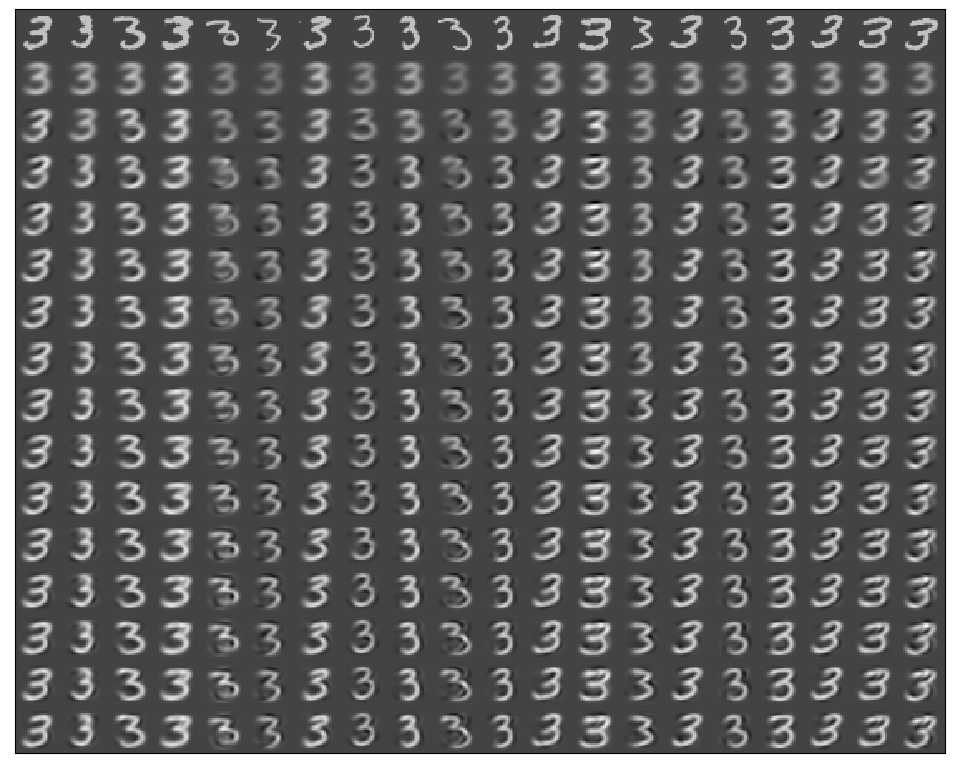

In [43]:
N = 20
M = np.array(Digit)[:, 0:N]
q = np.arange(1,31,2)
U, E, VT = svd(Digit, full_matrices = False)
for i, r in enumerate(q):
    Xq = U[:, :r]@ np.diag(E[:r]) @ VT[:r, :]
    M = np.c_[M, Xq[:, :N]]
plt.figure(figsize=(12,12))
plt.imshow(montage(M, len(q)+1, N), cmap = 'gray', interpolation = 'none')
plt.xticks([])
plt.yticks([])
# plt,title('The Montage of handwriting digits')
plt.show()

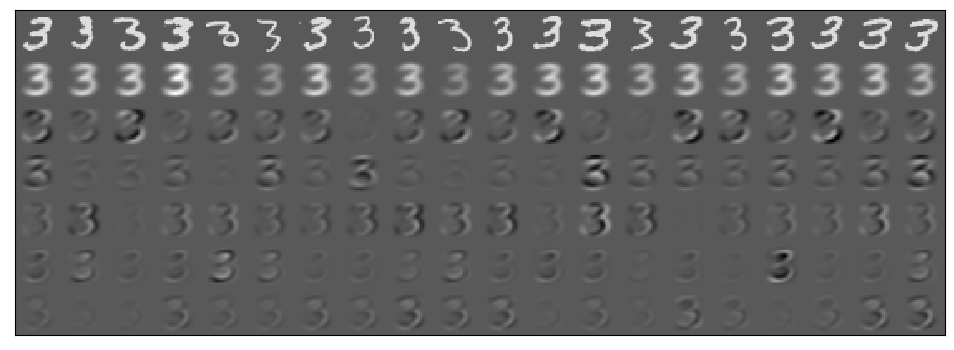

In [44]:
N = 20
q = np.arange(0,6)
U, E, VT = svd(Digit, full_matrices = False)
# tmp = E[0] *U[:, 0],reshape(-1,1)@vT[O, :].reshape(1,-1)
# M = tmp[:N, :] # 1st component
M = np.array(Digit)[:, 0:N]
for i, r in enumerate(q):
    Xq_th = E[r]* U[:, r].reshape(-1,1)@VT[r, :].reshape(1,-1)
    M = np.c_[M, Xq_th[:, :N]]
plt.figure(figsize=(12,12))
plt.imshow(montage(M, len(q)+1, N), cmap = 'gray', interpolation = 'none')
plt.xticks([])
plt.yticks([])
# plt,title('The Montage of handwriting digits')
plt.show()